In [17]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Connect to SQL Database

In [18]:
# Load dataset from SQLite
with sqlite3.connect("spotify_dataset.db") as conn:
    df_tracks = pd.read_sql_query("SELECT * FROM spotify_tracks;", conn)

In [19]:
# Count duplicated rows based on track_name and artists
duplicated_rows = df_tracks.duplicated(subset=['track_name', 'artists']).sum()

if duplicated_rows == 0:
    print('There are 0 duplicate rows based on song name and artist.')
else:
    print(f'There are {duplicated_rows} duplicate rows based on song name and artist. Dropping them now...')
    
    # Drop duplicates based on track_name and artists, keeping the first occurrence
    df_tracks = df_tracks.drop_duplicates(subset=['track_name', 'artists'], keep='first')

    print(f'After dropping duplicates, there are {df_tracks.shape[0]} rows left.')


There are 32656 duplicate rows based on song name and artist. Dropping them now...
After dropping duplicates, there are 81344 rows left.


## Create Test Playlist

From our EDA, we learned which song metrics were highly correlated. Out of those I chose to work with 'loudness' and 'energy' to create a sample playlist of songs while we work on collecting more data.

In [20]:
# Select relevant features
features = ['loudness', 'energy']
df_selected = df_tracks[features]

# Normalize the features for better distance calculation
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

In [21]:
""" 
Fit k-NN model, want to choose 30 songs for playlist so set n_neighbors to 30
"""
knn = NearestNeighbors(n_neighbors=30, metric='euclidean')
knn.fit(df_scaled)

NearestNeighbors(metric='euclidean', n_neighbors=30)

In [22]:

def create_similar_playlist(reference_song, n=300):
    """Function to recommend similar songs
    Args:
        reference_song: db with one row containing the correlating metrics
        n : number of songs we want in our playlist

    Returns:
        recommended_tracks: db full of n songs with similar quantitvate features
    """
    # Extract energy & danceability of reference song
    ref_features = reference_song[features].values.reshape(1, -1)
    
    # Scale the reference song using the same scaler
    ref_scaled = scaler.transform(ref_features)
    
    # Find nearest neighbors
    distances, indices = knn.kneighbors(ref_scaled, n_neighbors=n)
    
    # Get recommended songs
    recommended_tracks = df_tracks.iloc[indices[0]]
    
    return recommended_tracks

Choose a random song to base the playlist off of

In [23]:
# Example: Choose a random seed song
reference_song = df_tracks.sample(1)  # Pick a random song
reference_song[['track_name', 'artists', 'loudness', 'energy', 'track_genre']]

,track_name,artists,loudness,energy,track_genre
31313,Beautiful,Bazzi;Camila Cabello,-4.722,0.717,electro


A spotify user will generally have many songs saved in their playlists, so I chose to have about 300 songs in this playlist. 

In [24]:
""" Generate a playlist of 300 generally similar songs, showing their correlated features, name, and genre """

playlist = create_similar_playlist(reference_song)
playlist[['track_id','track_name', 'artists', 'loudness', 'energy', 'track_genre']]

c:\Users\avajt\anaconda3\envs\PIC16B-25W\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,track_id,track_name,artists,loudness,energy,track_genre
31313,7MDtE1tjuPZAro0aPYRql4,Beautiful,Bazzi;Camila Cabello,-4.722,0.717,electro
20901,4VUwkH455At9kENOfzTqmF,Beautiful (feat. Camila Cabello),Bazzi;Camila Cabello,-4.722,0.717,dance
60188,4mHCOjWOQKdgo6ttBx0Jin,落ちこぼれのスター,Banty Foot;EXPRESS,-4.710,0.717,j-dance
33368,7vSF7u4vWtZGrWCxTbAVaw,We'll Be Alright,RADWIMPS,-4.741,0.717,emo
66405,5fi3dnSJ41KSgfwTWn5rWx,Penguin Dance Chant,Jack Hartmann,-4.711,0.716,kids
...,...,...,...,...,...,...
113469,6YyizHBnH22hpC4R3CwJK5,One Thing Remains - Radio Version,Passion;Kristian Stanfill,-4.492,0.728,world-music
80163,0zHZSO80CTxNtvtRhveHRJ,Sau Aasmaan,Armaan Malik;Neeti Mohan,-4.930,0.729,pop-film
35905,7puqAESopmIgOGQupanrV8,De Mala e Cuia,Japãozin,-4.575,0.731,forro
108368,3l7VP8kWcgUvjt4p00KzG3,Kesäleski,Jaska Mäkynen,-4.987,0.708,tango


## Get Playlist Recommendation

In [25]:
# Select relevant numerical features
features = ['danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence']
df_filtered = playlist[features]

# Normalize the feature set
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_filtered)

In [26]:
# Split data into train and test sets (80% train, 20% test)
X_train, X_test = train_test_split(df_scaled, test_size=0.2, random_state=42)

Want to fine tune the KNN model to ensure we are choosing the best parameters.

In [27]:
def tune_knn(X_train, X_test, k_values=range(1, 101)):
    """ Function to find the best k value for KNN model
    """
    best_k = None
    best_score = float('inf')  # Lower score is better
    scores = []

    for k in k_values:
        knn = NearestNeighbors(n_neighbors=k, metric='cosine')
        knn.fit(X_train)
        
        # Find distances to test points
        distances, _ = knn.kneighbors(X_test, n_neighbors=k)
        
        # Compute Mean Squared Error (MSE)
        mse = np.mean(distances**2)
        scores.append((k, mse))
        
        # Track best k
        if mse < best_score:
            best_score = mse
            best_k = k
    
    return best_k, scores

In [28]:
# Find the best k value
best_k, scores = tune_knn(X_train, X_test)
print(f"Optimal number of neighbors: {best_k}")

Optimal number of neighbors: 1


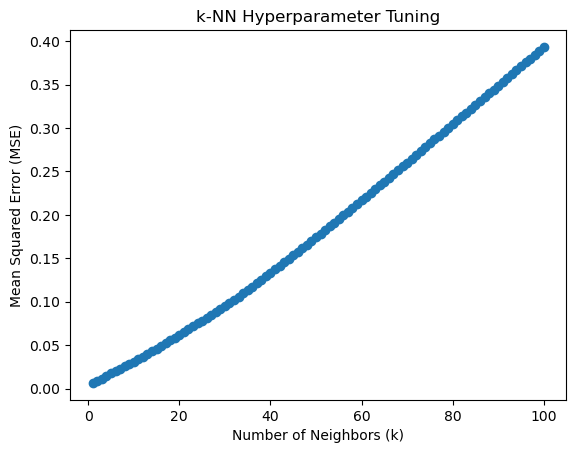

In [29]:
# Plot results
import matplotlib.pyplot as plt

k_values, mse_scores = zip(*scores)
plt.plot(k_values, mse_scores, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("k-NN Hyperparameter Tuning")
plt.show()

There are possible signs of overfitting since the best n_neighbor is 1, and the MSE scores are so accurate.

In [30]:
# Fit k-NN model with 7 features
knn = NearestNeighbors(n_neighbors=best_k, metric='cosine')
knn.fit(df_scaled)

NearestNeighbors(metric='cosine', n_neighbors=1)

We can now create a playlist based on the user's overall tracks. 

In [31]:
def recommend_songs(user_songs, genre=None, n=30):
    """ Function to recommend songs based on playlist
    Args: 
        user_songs: db full of playlists (rows must be >= n)
        genre: string, optional, genre provided by user to group tracks
        n: number of songs being recommended

    Returns:
        recommended_tracks: db which contains the n many recommended songs
    """
    
    # Filter dataset by genre if specified
    if genre:
        df_filtered = df_tracks[df_tracks['track_genre'].str.lower() == genre.lower()]
        if df_filtered.empty:
            print(f"Warning: No songs found for genre '{genre}'. Using all genres instead.")
            df_filtered = df_tracks  # Fall back to all songs
    else:
        df_filtered = df_tracks  # Use all genres if none specified

    # Ensure `n` does not exceed the number of available songs in the dataset
    max_neighbors = min(n, len(df_filtered))  

    # Ensure `user_songs` has enough entries
    num_user_songs = len(user_songs)
    if num_user_songs < max_neighbors:
        print(f"Warning: User provided only {num_user_songs} songs. Adjusting neighbors to {num_user_songs}.")
        max_neighbors = num_user_songs

    # Scale using the same scaler
    user_songs_scaled = scaler.transform(user_songs[features])

     # Fit a k-NN model specifically for the filtered dataset
    knn_filtered = NearestNeighbors(n_neighbors=max_neighbors, metric='euclidean')
    knn_filtered.fit(scaler.transform(df_filtered[features]))

    # Find nearest neighbors
    distances, indices = knn_filtered.kneighbors(user_songs_scaled, n_neighbors=max_neighbors)

    # Get recommended tracks from the filtered dataset
    recommended_tracks = df_filtered.iloc[indices[0]]

    return recommended_tracks[['track_name', 'artists', 'track_genre', 'danceability', 'energy', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'valence']]


In [33]:
# Example: Use generated playlist
recommendations = recommend_songs(playlist, genre='pop')
recommendations

,track_name,artists,track_genre,danceability,energy,tempo,speechiness,acousticness,instrumentalness,valence
81059,Dandelions - slowed + reverb,Ruth B.;slater,pop,0.573,0.715,101.699,0.0256,0.04440,0.000000,0.2580
81199,Mera Dil Bhi Kitna Pagal Hai - Recreated Version,Stebin Ben,pop,0.601,0.733,94.017,0.0362,0.33300,0.000002,0.3750
81756,Haaye Oye (feat. Ash King),QARAN;Ash King,pop,0.633,0.727,123.959,0.0383,0.17300,0.000000,0.5430
81607,Habibi - Albanian Remix,Ricky Rich;Dardan;DJ Gimi-O,pop,0.639,0.728,103.966,0.0301,0.02230,0.003840,0.0996
81073,Makhna,Tanishk Bagchi;Yasser Desai;Asees Kaur,pop,0.696,0.704,124.972,0.0423,0.16700,0.000000,0.4260
81460,Mood (feat. iann dior),24kGoldn;iann dior,pop,0.701,0.716,91.007,0.0361,0.17400,0.000000,0.7320
81766,Bamb Agya,Gur Sidhu;Jasmine Sandlas;Kaptaan,pop,0.823,0.709,93.012,0.0408,0.02350,0.000000,0.4990
81274,Loved By You,Justin Bieber;Burna Boy,pop,0.790,0.724,101.040,0.0852,0.06960,0.000002,0.6420
81137,Blank Space,Taylor Swift,pop,0.760,0.703,95.997,0.0540,0.10300,0.000000,0.5700
81170,"Najaa (From ""Sooryavanshi"")",Tanishk Bagchi;Pav Dharia;Nikhita Gandhi,pop,0.786,0.727,93.970,0.0510,0.08180,0.000000,0.6970
